##### ARTI 560 - Computer Vision

## Object Detection Using YOLOV8 with KerasCV - Exercise

In [5]:
import os
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
from PIL import Image
import matplotlib.pyplot as plt, keras_cv
from keras_cv import bounding_box, visualization

In [2]:
yolo = keras_cv.models.YOLOV8Detector.from_preset("yolo_v8_m_pascalvoc", bounding_box_format="xywh")

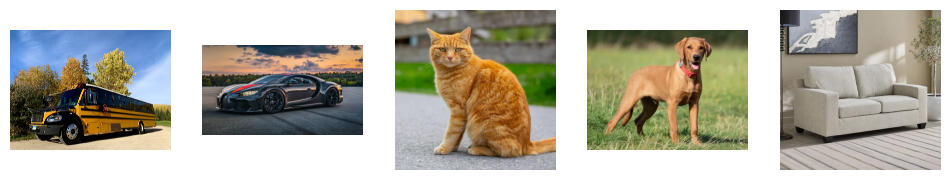

In [20]:
image_paths = [
    "/content/bus.jpg",
    "/content/car.jpg",
    "/content/cat.jpg",
    "/content/dog.jpg",
    "/content/sofa.jpg"
]

images = [np.array(Image.open(path).convert("RGB")) for path in image_paths]

# Display images
plt.figure(figsize=(12,4))
for i, img in enumerate(images):
    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.axis("off")
plt.show()

In [21]:
inference_resizing = keras_cv.layers.Resizing(
    640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
)
images_resized = np.array([inference_resizing(img) for img in images])

In [33]:
predictions = yolo.predict(images_resized, verbose=0)

voc_classes = {
    0:"aeroplane",1:"bicycle",2:"bird",3:"boat",4:"bottle",
    5:"bus",6:"car",7:"cat",8:"chair",9:"cow",
    10:"diningtable",11:"dog",12:"horse",13:"motorbike",14:"person",
    15:"pottedplant",16:"sheep",17:"sofa",18:"train",19:"tvmonitor"
}

for i in range(len(predictions["confidence"])):
    valid = predictions["confidence"][i] >= 0
    confs = predictions["confidence"][i][valid]
    clss  = predictions["classes"][i][valid].astype(int)
    print(f"Image {i+1}")
    for c, k in zip(confs, clss):
        print(f"{voc_classes[k]}: {float(c):.3f}")
    print()

Image 1
bus: 0.989

Image 2
car: 0.986

Image 3
cat: 0.973

Image 4
dog: 0.986

Image 5
sofa: 0.938



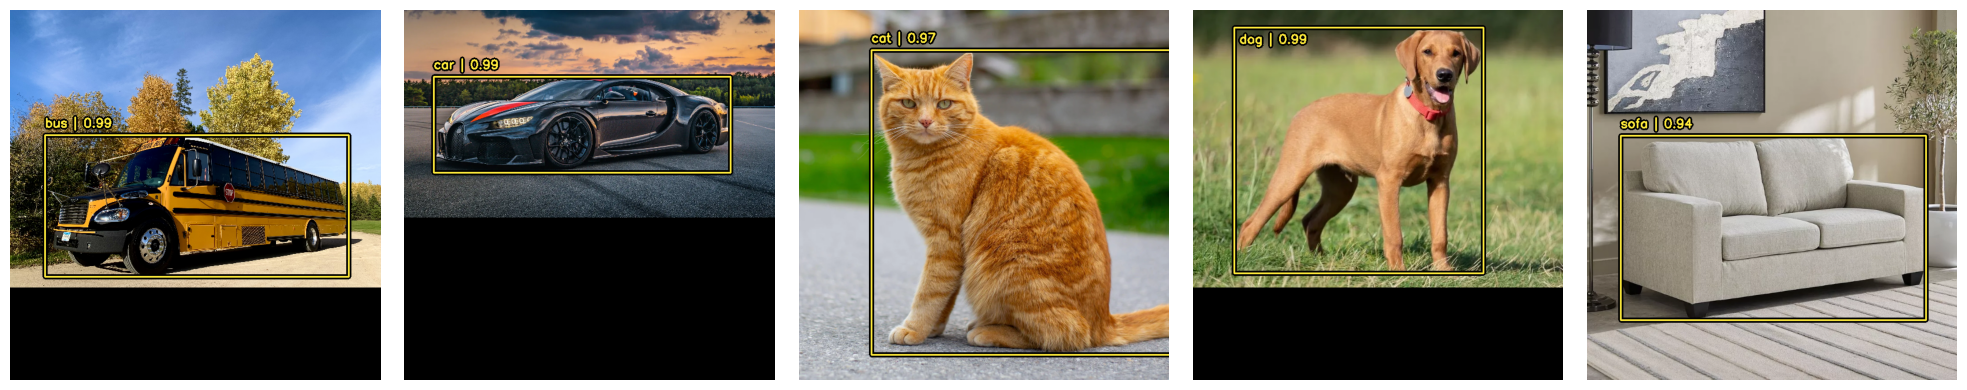

In [34]:
keras_cv.visualization.plot_bounding_box_gallery(
    images_resized,
    value_range=(0, 255),
    rows=1,
    cols=5,
    y_pred=predictions,
    class_mapping=voc_classes,
    scale=4,
    font_scale=0.7,
    bounding_box_format="xywh"
);